# 출시 전 LLM 리뷰 분석 보고서: Action 장르

## 분석 목적

이 보고서는 `Action` 장르와 유사한 Steam 인디게임의 출시 초기 리뷰를 LLM으로 분석하여,  
개발자가 출시 전 단계에서 **유저들이 어떤 요소를 긍정적으로 평가하고, 어떤 요소에 불만을 가지는지** 파악하는 것을 목적으로 한다.

## 핵심 질문

1. Action 장르 유저들은 어떤 요소를 긍정적으로 평가하는가?
2. Action 장르 유저들은 어떤 요소에 불만을 가지는가?
3. 긍정과 부정이 함께 나타나는 핵심 평가 축은 무엇인가?
4. 출시 전 체크리스트와 개발 우선순위로 연결할 수 있는 항목은 무엇인가?

## 사용 데이터

| 파일 | 역할 |
|---|---|
| `llm_review_analysis_result.csv` | 리뷰 1개 단위의 LLM 감성분석 결과 |
| `llm_issue_tags_flat.csv` | 리뷰 안에서 추출된 이슈 태그를 태그 단위로 펼친 결과 |

> 이 보고서는 특정 게임 1개의 패치 방향을 정하는 출시 후 분석이 아니라,  
> Action 장르 게임을 준비하는 개발자가 출시 전 단계에서 참고할 수 있는 **유사 장르 리뷰 기반 점검 보고서**이다.

# 1. 설정값

아래 설정값은 `03-1_run_llm_sentiment_Action_PreLaunch_v1.ipynb`에서 생성한 LLM 분석 결과를 불러오기 위한 경로 설정이다.

다른 환경에서 실행할 경우 `ROOT`만 본인 프로젝트 경로에 맞게 수정하면 된다.  
LLM 분석 결과 파일은 `data/outputs/main_action_d0-d30_1000` 폴더에 있다고 가정한다.

In [1]:
# ============================================================
# 데이터 분석용 라이브러리
# ============================================================
import platform
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


In [2]:
# 프로젝트 루트 직접 지정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정합니다.
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")

# ============================================================
# LLM 분석 산출물 폴더
# ============================================================
RUN_NAME = "main_action_d0-d30_1000"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# LLM 분석 산출물
RESULT_CSV_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
ISSUE_TAG_FLAT_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"

# 선택 산출물
GAME_SUMMARY_PATH = OUTPUT_DIR / "llm_game_summary.csv"
ISSUE_PRIORITY_PATH = OUTPUT_DIR / "llm_issue_priority_summary.csv"

print("\n프로젝트 루트:", ROOT)
print("전처리 후보 데이터:", RESULT_CSV_PATH)
print("전처리 게임 요약:", ISSUE_TAG_FLAT_PATH)
print("결과 저장 폴더:", OUTPUT_DIR)


프로젝트 루트: C:\Users\joon5\Documents\github\steam-indie-game-analysis
전처리 후보 데이터: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000\llm_review_analysis_result.csv
전처리 게임 요약: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000\llm_issue_tags_flat.csv
결과 저장 폴더: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000


# 2. 데이터 불러오기 및 기본 점검

출시 전 분석에서 핵심이 되는 데이터는 두 가지다.

| 데이터 | 분석 관점 |
|---|---|
| 리뷰 단위 데이터 | 리뷰별 Steam 라벨, LLM 감정, 주요 이슈, 긴급도 |
| 태그 단위 데이터 | 리뷰 안에서 반복적으로 추출된 칭찬 요인과 불만 요인 |

먼저 결과 파일이 정상적으로 불러와지는지, 분석 리뷰 수와 게임 수가 어느 정도인지 확인한다.

In [3]:
# ============================================================
# 데이터 불러오기
# ============================================================

df_result = pd.read_csv(RESULT_CSV_PATH)
df_tag = pd.read_csv(ISSUE_TAG_FLAT_PATH)

print("LLM 분석 결과 행 수:", len(df_result))
print("이슈 태그 행 수:", len(df_tag))
print("분석 게임 수:", df_result["appid"].nunique())

display(df_result.head())
display(df_tag.head())

LLM 분석 결과 행 수: 525
이슈 태그 행 수: 1067
분석 게임 수: 28


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,193552472,1054510,Survivalist: Invisible Strain,2025-04-25 13:52:54,2025-04-25,0.0,D0-D30,positive,63.216667,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'Definitely worth the price. Its a quite uniqu...",low,가격 대비 가치가 높고 독창적인 게임성을 가진 훌륭한 게임임.,"현재의 독창적인 게임성을 유지하며, 향후 업데이트에서도 가격 대비 만족도를 높일 수 있는 콘텐츠를 지속적으로 추가하십시오.",exact_match
1,success,193564502,1054510,Survivalist: Invisible Strain,2025-04-25 17:00:16,2025-04-25,0.0,D0-D30,positive,1006.266667,8.0,0.543334,positive,5.0,gameplay_loop,"[{'category': 'gameplay_loop', 'sentiment': 'positive', 'evidence': 'recruit NPCs to your community and have them do...",low,"NPC 관리 시스템과 좀비 감염 메커니즘이 뛰어나며, 다수 좀비와의 전투 밸런스 조정이 필요함.",NPC 관리 및 좀비 감염 시스템에 대한 유저 만족도가 높음. 다수 좀비와의 전투 밸런스를 검토하여 난이도 조절을 고려하십시오.,exact_match
2,success,193570077,1054510,Survivalist: Invisible Strain,2025-04-25 18:29:43,2025-04-25,0.0,D0-D30,positive,71.483333,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'game I can get lost in for hours'}, {'categor...",low,전략적 깊이가 있고 도전적인 난이도를 가진 몰입감 높은 게임임.,"높은 난이도와 전략적 깊이를 선호하는 유저층이 형성되어 있으므로, 현재의 도전적인 난이도 기조를 유지하십시오.",exact_match
3,success,193578442,1054510,Survivalist: Invisible Strain,2025-04-25 20:45:58,2025-04-25,0.0,D0-D30,positive,5.733333,0.0,0.478548,mixed,4.0,multiplayer_network,"[{'category': 'multiplayer_network', 'sentiment': 'negative', 'evidence': 'only one conversation going at a time, fr...",high,"게임 자체는 매우 훌륭하고 자유도가 높으나, 멀티플레이 시 한 번에 하나의 대화만 가능한 시스템이 협동 플레이를 저해함.","멀티플레이어 환경에서 NPC와의 대화 시스템을 독립적으로 처리할 수 있도록 개선하여, 여러 플레이어가 동시에 각기 다른 NPC와 대화할 수 있는 환경을 구축하세요.",partial_match
4,success,193594348,1054510,Survivalist: Invisible Strain,2025-04-26 02:06:16,2025-04-25,1.0,D0-D30,positive,241.783333,8.0,0.563492,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'best example of a labor of love, fun, hard, a...",low,"전작부터 발전해온 모습이 인상적이며, 장르적 특성을 잘 살린 완성도 높은 게임임.","현재의 게임 방향성을 유지하며, 기존 팬들이 만족하는 깊이 있는 게임플레이 요소를 지속적으로 업데이트하세요.",exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,193552472,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,63.216667,0.0,0.500000,positive_praise,긍정 칭찬,positive,Definitely worth the price. Its a quite unique game
1,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,recruit NPCs to your community and have them do all the tedious stuff
2,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,infect your opponents with the zombie virus
3,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,balance,밸런스,neutral,Combat against zombies can be dicey when faced against multiple opponents
4,193570077,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,71.483333,0.0,0.500000,positive_praise,긍정 칭찬,positive,game I can get lost in for hours


## 2-1. 데이터 품질 점검 요약

`check_Action_PreLaunch.ipynb`에서 확인한 품질 점검 관점을 보고서에도 간단히 반영한다.

현재 결과는 총 **525개 리뷰**, **28개 게임**으로 구성되어 있으며, LLM 분석 상태는 모두 `success`로 확인되었다.  
또한 중복 리뷰 ID가 없고, 출시 후 경과일도 `D0-D30` 범위 안에 있어 출시 전 분석용 초기 리뷰 표본으로 사용할 수 있다.

다만 장르당 1,000개 이상이라는 최종 확대 목표에는 미달하므로, 본 보고서에서는 **Action 장르 1차 본 분석 결과**로 해석한다.

In [4]:
# ============================================================
# 2-1. 데이터 품질 점검 요약
# ============================================================

reviews_without_tags = set(df_result["recommendationid"]) - set(df_tag["recommendationid"])

quality_summary = pd.DataFrame({
    "점검 항목": [
        "분석 결과 행 수",
        "분석 게임 수",
        "분석 성공 수",
        "중복 리뷰 ID 수",
        "리뷰 기간",
        "출시 후 경과일 범위",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "이슈 태그 없는 리뷰 수",
    ],
    "값": [
        len(df_result),
        df_result["appid"].nunique(),
        (df_result["analysis_status"] == "success").sum(),
        df_result["recommendationid"].duplicated().sum(),
        ", ".join(df_result["release_period"].dropna().unique()),
        f"{df_result['days_from_release'].min():.0f} ~ {df_result['days_from_release'].max():.0f}",
        (df_result["steam_label_text"] == "positive").sum(),
        (df_result["steam_label_text"] == "negative").sum(),
        len(reviews_without_tags),
    ]
})

display(quality_summary)

,점검 항목,값
0,분석 결과 행 수,525
1,분석 게임 수,28
2,분석 성공 수,525
3,중복 리뷰 ID 수,0
4,리뷰 기간,D0-D30
5,출시 후 경과일 범위,0 ~ 30
6,Steam 긍정 리뷰 수,342
7,Steam 부정 리뷰 수,183
8,이슈 태그 없는 리뷰 수,1


# 3. 출시 전 분석 대상 요약

이번 분석은 Action 장르에 해당하는 유사 게임들의 출시 초기 리뷰를 대상으로 한다.

| 항목 | 내용 |
|---|---|
| 분석 관점 | 출시 전 분석 |
| 분석 대상 | Action 장르 유사 게임들의 출시 초기 리뷰 |
| 출시일 기준 | 2024-01-01 이후 |
| 리뷰 구간 | D0-D30 |
| 리뷰 언어 | English |
| 리뷰 조건 | Steam 구매 리뷰, 무료 수령 리뷰 제외, 얼리액세스 리뷰 제외 |
| 샘플링 방식 | Steam 긍정/부정 라벨 균형 샘플링 |
| 최종 분석 리뷰 수 | 525개 |
| 최종 분석 게임 수 | 28개 |

현재 샘플링은 긍정/부정 균형을 목표로 했지만, 일부 게임은 D0-D30 구간의 부정 리뷰 수가 부족해 최종 표본은 positive 342개, negative 183개로 구성되었다.  
따라서 본문 분석에서는 표본 내 긍정/부정 비율과 실제 Steam 긍정률을 구분해서 해석해야 한다.

In [5]:
# ============================================================
# 3. 출시 전 분석 대상 요약
# ============================================================

basic_summary = pd.DataFrame({
    "항목": [
        "분석 관점",
        "분석 대상",
        "리뷰 구간",
        "최종 분석 리뷰 수",
        "최종 분석 게임 수",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "LLM 분석 성공률",
    ],
    "내용": [
        "출시 전 분석",
        "Action 장르 유사 게임들의 출시 초기 리뷰",
        ", ".join(df_result["release_period"].dropna().unique()),
        f"{len(df_result):,}개",
        f"{df_result['appid'].nunique():,}개",
        f"{(df_result['steam_label_text'] == 'positive').sum():,}개",
        f"{(df_result['steam_label_text'] == 'negative').sum():,}개",
        f"{(df_result['analysis_status'] == 'success').mean() * 100:.1f}%",
    ]
})

display(basic_summary)

,항목,내용
0,분석 관점,출시 전 분석
1,분석 대상,Action 장르 유사 게임들의 출시 초기 리뷰
2,리뷰 구간,D0-D30
3,최종 분석 리뷰 수,525개
4,최종 분석 게임 수,28개
5,Steam 긍정 리뷰 수,342개
6,Steam 부정 리뷰 수,183개
7,LLM 분석 성공률,100.0%


# 4. 전체 LLM 감정 분석 결과 요약

Steam 라벨은 유저가 최종적으로 추천했는지 여부를 보여준다.  
반면 LLM 감정은 리뷰 본문을 읽고 긍정, 부정, 혼합, 중립을 더 세부적으로 구분한다.

따라서 두 지표를 함께 보면, Action 장르 유저가 단순히 추천/비추천을 남긴 것뿐 아니라, 리뷰 본문 안에서 어떤 만족과 불만을 표현했는지 확인할 수 있다.

In [6]:
# ============================================================
# 4. 전체 LLM 감정 분석 결과 요약
# ============================================================

steam_label_summary = (
    df_result["steam_label_text"]
    .value_counts()
    .rename_axis("steam_label_text")
    .reset_index(name="review_count")
)
steam_label_summary["ratio_percent"] = (steam_label_summary["review_count"] / len(df_result) * 100).round(1)

llm_sentiment_summary = (
    df_result["llm_sentiment"]
    .value_counts()
    .rename_axis("llm_sentiment")
    .reset_index(name="review_count")
)
llm_sentiment_summary["ratio_percent"] = (llm_sentiment_summary["review_count"] / len(df_result) * 100).round(1)

print("[Steam 라벨 분포]")
display(steam_label_summary)

print("[LLM 감정 분포]")
display(llm_sentiment_summary)

[Steam 라벨 분포]


,steam_label_text,review_count,ratio_percent
0,positive,342,65.1
1,negative,183,34.9


[LLM 감정 분포]


,llm_sentiment,review_count,ratio_percent
0,positive,317,60.4
1,negative,174,33.1
2,mixed,32,6.1
3,neutral,2,0.4


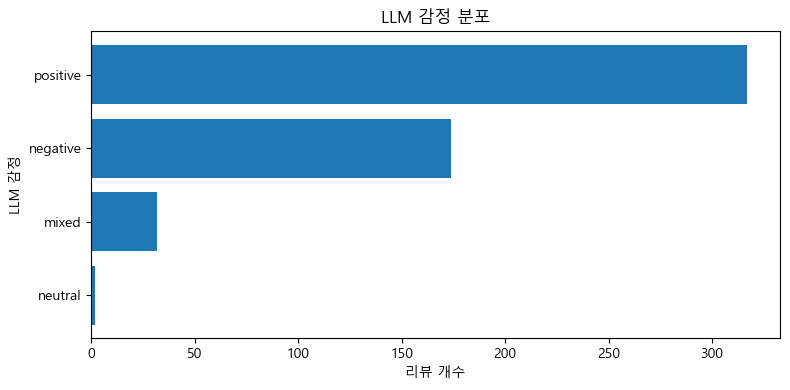

In [7]:
# ============================================================
# 4-1. LLM 감정 분포 그래프
# ============================================================

plot_df = llm_sentiment_summary.sort_values("review_count", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["llm_sentiment"], plot_df["review_count"])
plt.title("LLM 감정 분포")
plt.xlabel("리뷰 개수")
plt.ylabel("LLM 감정")
plt.tight_layout()
plt.show()

## 결과 해석

표본 내 Steam 긍정 리뷰는 **342개(65.1%)**, 부정 리뷰는 **183개(34.9%)**로 나타났다.  
LLM 기준으로는 긍정 317개, 부정 174개, 혼합 32개, 중립 2개로 분류되었다.

즉, Action 장르 출시 초기 리뷰에서는 전반적으로 긍정 반응이 더 많았지만, 부정 또는 혼합으로 해석되는 리뷰도 적지 않게 존재한다.  
출시 전 분석에서는 이 부정·혼합 리뷰에 포함된 불편 요소를 확인해 출시 전 체크리스트로 연결하는 것이 중요하다.

# 5. Steam 라벨과 LLM 감정 비교

Steam 추천/비추천 라벨과 LLM 감정 판단은 항상 완전히 같은 의미는 아니다.

예를 들어 Steam에서는 추천 리뷰이지만, 본문에는 조작감이나 반복성에 대한 아쉬움이 함께 들어 있을 수 있다.  
반대로 비추천 리뷰라도 특정 장점은 인정하는 경우가 있다.

이 섹션에서는 Steam 라벨과 LLM 감정의 관계를 확인하여, 단순 추천 여부만으로 놓칠 수 있는 개선 요구를 살펴본다.

In [8]:
# ============================================================
# 5. Steam 라벨과 LLM 감정 비교
# ============================================================

sentiment_relation_summary = (
    df_result["sentiment_relation"]
    .value_counts()
    .rename_axis("sentiment_relation")
    .reset_index(name="review_count")
)
sentiment_relation_summary["ratio_percent"] = (sentiment_relation_summary["review_count"] / len(df_result) * 100).round(1)

display(sentiment_relation_summary)

sentiment_cross = pd.crosstab(
    df_result["steam_label_text"],
    df_result["llm_sentiment"],
    margins=True
)

display(sentiment_cross)

,sentiment_relation,review_count,ratio_percent
0,exact_match,491,93.5
1,partial_match,32,6.1
2,unclear,2,0.4


llm_sentiment,mixed,negative,neutral,positive,All
steam_label_text,,,,,
negative,9,174,0,0,183
positive,23,0,2,317,342
All,32,174,2,317,525


## 결과 해석

Steam 라벨과 LLM 감정 판단은 대부분 일치하거나 부분적으로 일치했다.  
`exact_match`는 491개, `partial_match`는 32개였고, `unclear`는 2개에 그쳤다.

이는 LLM 결과가 Steam 추천/비추천 라벨과 크게 어긋나지 않으며, 리뷰 본문을 세부적으로 해석하는 보조 지표로 사용할 수 있음을 의미한다.  
다만 `partial_match`는 긍정 리뷰 안의 불만, 부정 리뷰 안의 장점처럼 복합적인 반응을 보여줄 수 있으므로 별도로 해석할 가치가 있다.

# 6. Action 장르 유저가 긍정적으로 평가한 요소

이 섹션에서는 LLM이 긍정 방향으로 분류한 이슈 태그를 집계한다.

`positive_praise`는 “재밌다”, “좋다”처럼 전반적 만족 표현에 가깝다.  
따라서 출시 전 전략으로 연결하기 위해서는 `positive_praise`를 포함한 전체 순위와, 이를 제외한 구체적 강점 순위를 함께 확인한다.

In [9]:
# ============================================================
# 6. Action 장르 유저가 긍정적으로 평가한 요소
# ============================================================

positive_tag_summary = (
    df_tag[df_tag["tag_sentiment"] == "positive"]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        positive_tag_count=("recommendationid", "size"),
        affected_reviews=("recommendationid", "nunique"),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["affected_reviews", "positive_tag_count"], ascending=False)
)

positive_tag_summary["avg_playtime_hours"] = positive_tag_summary["avg_playtime_hours"].round(1)

display(positive_tag_summary)

# positive_praise를 제외한 구체적 강점
positive_specific_summary = positive_tag_summary[positive_tag_summary["tag_category"] != "positive_praise"].copy()
display(positive_specific_summary.head(10))

,tag_category,issue_name_kor,positive_tag_count,affected_reviews,avg_playtime_hours
10,positive_praise,긍정 칭찬,307,305,15.6
5,gameplay_loop,게임플레이 루프,57,56,47.3
6,graphics_audio,그래픽/사운드,26,26,3.6
4,difficulty,난이도,19,19,12.3
12,story,스토리,11,11,45.9
1,content_volume,콘텐츠 분량,10,10,13.2
11,price_value,가격/가치,7,7,4.5
3,developer_communication,개발사 소통,6,6,30.6
13,ui_ux,UI/UX,5,5,6.8
2,control,조작감,4,4,2.2


,tag_category,issue_name_kor,positive_tag_count,affected_reviews,avg_playtime_hours
5,gameplay_loop,게임플레이 루프,57,56,47.3
6,graphics_audio,그래픽/사운드,26,26,3.6
4,difficulty,난이도,19,19,12.3
12,story,스토리,11,11,45.9
1,content_volume,콘텐츠 분량,10,10,13.2
11,price_value,가격/가치,7,7,4.5
3,developer_communication,개발사 소통,6,6,30.6
13,ui_ux,UI/UX,5,5,6.8
2,control,조작감,4,4,2.2
9,performance,성능,4,4,5.4


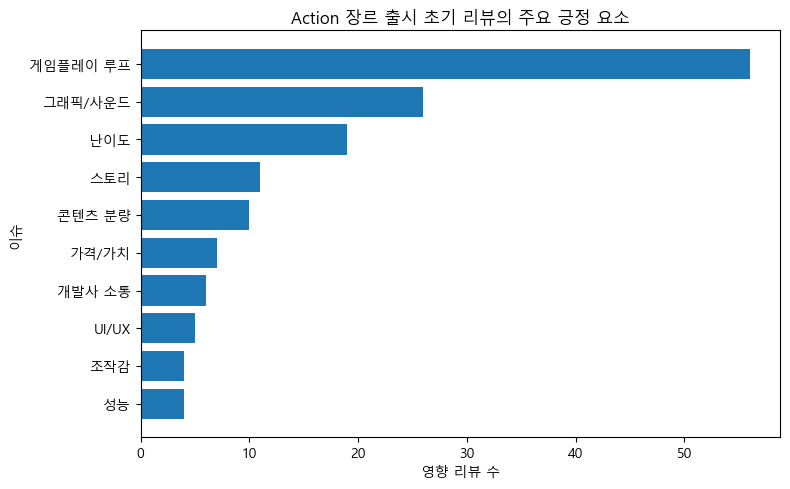

In [10]:
# ============================================================
# 6-1. 구체적 긍정 요소 그래프
# ============================================================

plot_df = positive_specific_summary.head(10).sort_values("affected_reviews", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["issue_name_kor"], plot_df["affected_reviews"])
plt.title("Action 장르 출시 초기 리뷰의 주요 긍정 요소")
plt.xlabel("영향 리뷰 수")
plt.ylabel("이슈")
plt.tight_layout()
plt.show()

## 결과 해석

긍정 태그에서는 **긍정 칭찬(306개)**이 가장 많았다.  
구체적 강점만 보면 **게임플레이 루프(56개 리뷰)**, **그래픽/사운드(26개 리뷰)**, **난이도(19개 리뷰)**, **스토리(11개 리뷰)**, **콘텐츠 분량(10개 리뷰)** 순으로 나타났다.

이는 Action 장르에서 유저들이 단순히 시각적 완성도만 보는 것이 아니라, 전투·이동·반복 플레이 구조와 같은 핵심 플레이 경험을 중요하게 평가한다는 뜻이다.  
따라서 출시 전에는 핵심 전투 루프, 조작 반응, 타격감, 반복 플레이 동기가 짧은 플레이 시간 안에도 충분히 전달되는지 확인해야 한다.

# 7. Action 장르 유저가 불만을 가진 요소

출시 전 분석에서 가장 중요한 부분은 유사 장르 게임에서 반복적으로 나타난 부정 요인을 파악하는 것이다.

이 섹션에서는 부정 태그를 기준으로 다음 항목을 확인한다.

| 항목 | 의미 |
|---|---|
| 부정 태그 수 | 해당 이슈가 태그로 추출된 횟수 |
| 영향 리뷰 수 | 몇 개 리뷰에서 해당 문제가 나타났는지 |
| High urgency 리뷰 수 | LLM이 빠른 확인이 필요하다고 판단한 리뷰 수 |
| 평균 플레이타임 | 초반 이탈 문제인지, 일정 플레이 후 누적 불만인지 참고 |

In [11]:
# ============================================================
# 7. Action 장르 유저가 불만을 가진 요소
# ============================================================

negative_tag_summary = (
    df_tag[df_tag["tag_sentiment"] == "negative"]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        negative_tag_count=("recommendationid", "size"),
        affected_reviews=("recommendationid", "nunique"),
        high_urgency_reviews=("urgency", lambda x: (x == "high").sum()),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["affected_reviews", "negative_tag_count"], ascending=False)
)

negative_tag_summary["avg_playtime_hours"] = negative_tag_summary["avg_playtime_hours"].round(1)

display(negative_tag_summary)

,tag_category,issue_name_kor,negative_tag_count,affected_reviews,high_urgency_reviews,avg_playtime_hours
7,gameplay_loop,게임플레이 루프,118,112,74,9.3
1,bug,버그,60,59,44,17.5
3,control,조작감,52,52,32,13.4
18,ui_ux,UI/UX,50,49,29,17.4
0,balance,밸런스,40,38,31,23.6
6,difficulty,난이도,34,34,22,10.4
12,other,기타,29,26,9,23.5
2,content_volume,콘텐츠 분량,26,26,17,17.3
8,graphics_audio,그래픽/사운드,23,23,12,10.8
15,progression_grind,성장/반복 노가다,23,23,7,16.6


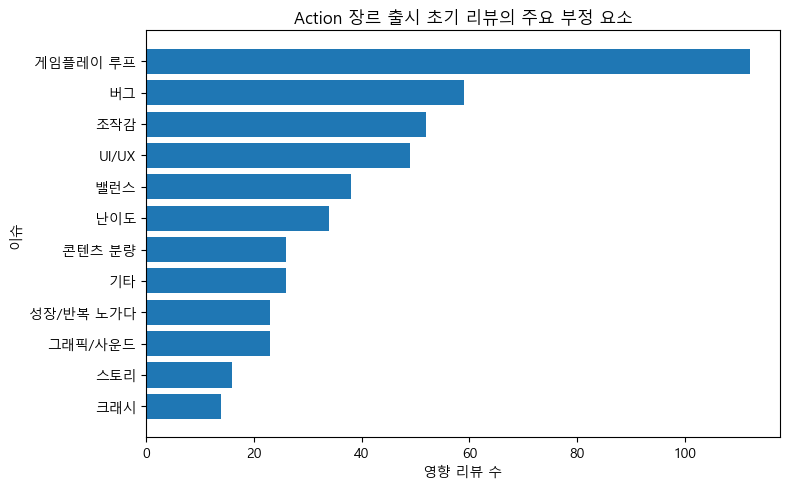

In [12]:
# ============================================================
# 7-1. 주요 부정 요소 그래프
# ============================================================

plot_df = negative_tag_summary.head(12).sort_values("affected_reviews", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["issue_name_kor"], plot_df["affected_reviews"])
plt.title("Action 장르 출시 초기 리뷰의 주요 부정 요소")
plt.xlabel("영향 리뷰 수")
plt.ylabel("이슈")
plt.tight_layout()
plt.show()

## 결과 해석

부정 태그에서는 **게임플레이 루프(111개 리뷰)**, **버그(59개 리뷰)**, **조작감(52개 리뷰)**, **UI/UX(49개 리뷰)**, **밸런스(37개 리뷰)**, **난이도(35개 리뷰)**가 상위에 나타났다.

이 결과는 Action 장르의 출시 초기 부정 반응이 단순한 취향 차이보다는, 실제 플레이 경험을 방해하는 요소에서 많이 발생한다는 것을 보여준다.  
특히 게임플레이 루프, 조작감, UI/UX, 밸런스, 난이도는 게임의 핵심 재미와 직접 연결되므로 출시 전 테스트에서 우선 확인해야 한다.

또한 버그, 크래시, 저장/진행, 성능 문제는 High urgency 비중이 높아, 출시 직전 QA 단계에서 별도 체크리스트로 관리할 필요가 있다.

# 8. 긍정과 부정이 함께 나타난 핵심 평가 축

일부 이슈는 긍정과 부정 양쪽에서 모두 많이 등장한다.  
이런 이슈는 단순한 장점이나 단점이 아니라, Action 장르 유저 평가를 좌우하는 핵심 축으로 보는 것이 적절하다.

예를 들어 게임플레이 루프는 잘 설계되면 강점이 되지만, 반복성이 약하거나 전투·이동 구조가 불편하면 곧바로 부정 평가로 이어질 수 있다.

In [13]:
# ============================================================
# 8. 긍정과 부정이 함께 나타난 핵심 평가 축
# ============================================================

issue_sentiment_pivot = pd.crosstab(
    df_tag["issue_name_kor"],
    df_tag["tag_sentiment"]
)

for col in ["positive", "negative", "mixed", "neutral"]:
    if col not in issue_sentiment_pivot.columns:
        issue_sentiment_pivot[col] = 0

issue_sentiment_pivot["total"] = issue_sentiment_pivot[["positive", "negative", "mixed", "neutral"]].sum(axis=1)
issue_sentiment_pivot = issue_sentiment_pivot.sort_values("total", ascending=False)

display(issue_sentiment_pivot)

# 긍정과 부정이 모두 존재하는 이슈만 확인
both_side_issues = issue_sentiment_pivot[
    (issue_sentiment_pivot["positive"] > 0) &
    (issue_sentiment_pivot["negative"] > 0)
].copy()

display(both_side_issues)

tag_sentiment,mixed,negative,neutral,positive,total
issue_name_kor,,,,,
긍정 칭찬,0,0,0,307,307
게임플레이 루프,3,118,11,57,189
난이도,2,34,7,19,62
버그,1,60,0,0,61
UI/UX,0,50,5,5,60
조작감,1,52,2,4,59
그래픽/사운드,1,23,6,26,56
콘텐츠 분량,0,26,11,10,47
밸런스,0,40,4,2,46


tag_sentiment,mixed,negative,neutral,positive,total
issue_name_kor,,,,,
게임플레이 루프,3,118,11,57,189
난이도,2,34,7,19,62
UI/UX,0,50,5,5,60
조작감,1,52,2,4,59
그래픽/사운드,1,23,6,26,56
콘텐츠 분량,0,26,11,10,47
밸런스,0,40,4,2,46
기타,1,29,9,1,40
스토리,0,16,2,11,29


## 결과 해석

긍정과 부정이 함께 나타난 대표 이슈는 **게임플레이 루프, 난이도, UI/UX, 조작감, 그래픽/사운드, 콘텐츠 분량, 밸런스**였다.

특히 게임플레이 루프는 긍정 57개, 부정 117개로 양쪽 모두에서 많이 등장했다.  
이는 Action 장르에서 핵심 플레이 구조가 유저 평가의 중심이라는 의미다.

따라서 출시 전에는 “재미있는 콘셉트인가?”만 확인하는 것이 아니라, 실제 플레이 과정에서 다음 요소가 제대로 작동하는지 점검해야 한다.

- 전투와 이동이 반복해도 피로하지 않은가
- 조작 반응과 카메라가 불편하지 않은가
- 난이도 상승이 납득 가능한가
- UI가 초반 목표와 조작 방법을 충분히 안내하는가
- 콘텐츠 분량과 반복 플레이 동기가 가격대와 기대치에 맞는가

# 9. 시급도 기준으로 본 출시 전 리스크

`urgency`는 LLM이 리뷰 본문을 읽고 개선 시급도를 판단한 값이다.  
출시 전 분석에서는 이를 실제 장애 지표로 보기보다는, 유저가 어떤 문제를 심각하게 받아들였는지 확인하는 보조 기준으로 사용한다.

In [14]:
# ============================================================
# 9. 시급도 기준으로 본 출시 전 리스크
# ============================================================

urgency_summary = (
    df_result["urgency"]
    .value_counts()
    .rename_axis("urgency")
    .reset_index(name="review_count")
)
urgency_summary["ratio_percent"] = (urgency_summary["review_count"] / len(df_result) * 100).round(1)

display(urgency_summary)

high_urgency_issue_summary = (
    df_tag[(df_tag["tag_sentiment"] == "negative") & (df_tag["urgency"] == "high")]
    .groupby(["tag_category", "issue_name_kor"], as_index=False)
    .agg(
        high_urgency_tag_count=("recommendationid", "size"),
        affected_reviews=("recommendationid", "nunique"),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
    )
    .sort_values(["affected_reviews", "high_urgency_tag_count"], ascending=False)
)
high_urgency_issue_summary["avg_playtime_hours"] = high_urgency_issue_summary["avg_playtime_hours"].round(1)

display(high_urgency_issue_summary)

,urgency,review_count,ratio_percent
0,low,278,53.0
1,high,140,26.7
2,medium,107,20.4


,tag_category,issue_name_kor,high_urgency_tag_count,affected_reviews,avg_playtime_hours
7,gameplay_loop,게임플레이 루프,74,68,9.6
1,bug,버그,44,43,15.9
3,control,조작감,32,32,6.0
0,balance,밸런스,31,30,13.8
18,ui_ux,UI/UX,29,29,6.2
6,difficulty,난이도,22,22,5.0
2,content_volume,콘텐츠 분량,17,17,15.6
4,crash,크래시,14,14,13.6
8,graphics_audio,그래픽/사운드,12,12,10.5
16,save_progression,저장/진행,12,11,14.4


## 결과 해석

전체 리뷰 중 High urgency는 140개로 나타났다.  
High urgency 부정 이슈에서는 **게임플레이 루프, 버그, 조작감, 밸런스, UI/UX, 난이도**가 주로 확인되었다.

이는 Action 장르 출시 전 QA에서 단순히 버그만 보는 것이 아니라, 핵심 플레이 경험 자체가 유저에게 불편하게 받아들여지는지도 함께 확인해야 함을 의미한다.

# 10. 게임별 샘플 수 확인

이번 분석은 특정 게임 하나가 아니라 Action 장르 유사 게임 묶음을 보는 출시 전 분석이다.  
따라서 게임별 리뷰 수가 지나치게 한쪽에 몰려 있는지 확인할 필요가 있다.

단, 일부 게임은 D0-D30 조건에서 리뷰 수가 적기 때문에 게임별 세부 비교보다는 장르 전체의 반복 이슈를 중심으로 해석하는 것이 안전하다.

In [15]:
# ============================================================
# 10. 게임별 샘플 수 확인
# ============================================================

game_sample_summary = (
    df_result
    .groupby(["appid", "game_name"], as_index=False)
    .agg(
        sample_reviews=("recommendationid", "count"),
        positive_reviews=("steam_label_text", lambda x: (x == "positive").sum()),
        negative_reviews=("steam_label_text", lambda x: (x == "negative").sum()),
        high_urgency_reviews=("urgency", lambda x: (x == "high").sum()),
        avg_sentiment_score=("sentiment_score", "mean"),
    )
    .sort_values("sample_reviews", ascending=False)
)

game_sample_summary["avg_sentiment_score"] = game_sample_summary["avg_sentiment_score"].round(2)

display(game_sample_summary)

display(game_sample_summary["sample_reviews"].describe())

,appid,game_name,sample_reviews,positive_reviews,negative_reviews,high_urgency_reviews,avg_sentiment_score
11,2101890,Zoonomaly,50,25,25,19,2.90
6,1585180,Drova - Forsaken Kin,50,25,25,9,3.24
14,2488510,FatalZone,50,18,32,20,2.58
24,3027930,Karate Survivor,49,25,24,19,3.24
16,2514460,GUARDS!,48,24,24,21,3.02
4,1466060,Tainted Grail: The Fall of Avalon,47,23,24,17,3.09
3,1409200,HYPERVIOLENT,41,30,11,12,3.59
0,1054510,Survivalist: Invisible Strain,38,29,9,11,3.76
17,2617090,Fowl Damage,36,36,0,0,4.94
23,3001200,Tails Noir: Rebel Rush,32,32,0,0,4.88


count    28.000000
mean     18.750000
std      19.912075
min       1.000000
25%       2.750000
50%       7.000000
75%      38.750000
max      50.000000
Name: sample_reviews, dtype: float64

## 결과 해석

게임별 표본 수는 최대 50개, 최소 1개로 차이가 있다.  
일부 게임은 긍정 리뷰만 포함되거나 표본 수가 적어 개별 게임 단위 해석에는 한계가 있다.

따라서 본 보고서에서는 개별 게임 순위보다 **Action 장르 전체에서 반복적으로 나타난 긍정·부정 요인**을 중심으로 해석한다.  
게임별 비교가 필요하다면 표본 수가 30개 이상인 게임을 중심으로 별도 분석하는 것이 적절하다.

# 11. 출시 전 점검 항목 도출

LLM 분석에서 반복적으로 확인된 긍정·부정 요소를 바탕으로, Action 장르 인디게임 개발자가 출시 전 단계에서 점검해야 할 항목을 정리한다.

| 점검 영역          | 점검 질문                                    | 관련 이슈                   | 권장 대응                                |
| -------------- | ---------------------------------------- | ----------------------- | ------------------------------------ |
| 핵심 플레이 루프      | 전투, 이동, 반복 플레이 구조가 짧은 시간 안에도 재미있게 전달되는가? | 게임플레이 루프                | 프로토타입/데모 단계에서 핵심 루프 반복 테스트를 우선 진행    |
| 조작감            | 입력 반응, 카메라, 이동 방식, 키 설정이 불편하지 않은가?       | 조작감                     | 조작 튜토리얼, 키 리바인딩, 카메라 옵션, 피드백 효과 점검   |
| UI/UX와 초반 안내   | 초반 목표, 메뉴, 인벤토리, 튜토리얼이 직관적으로 안내되는가?      | UI/UX                   | 첫 10~30분 플레이 구간에서 목표 안내와 메뉴 접근성 테스트  |
| 난이도와 밸런스       | 초반 난이도가 과도하거나, 특정 구간에서 불합리하게 느껴지지 않는가?   | 난이도, 밸런스                | 난이도 곡선과 실패 후 재도전 경험을 별도 점검           |
| 버그와 기술 안정성     | 진행 불가, 저장 오류, 크래시, 성능 저하 문제가 없는가?        | 버그, 크래시, 저장/진행, 성능, 최적화 | 출시 직전 QA에서 진행 불가/크래시/저장 문제를 우선 점검    |
| 콘텐츠 밀도와 반복 피로도 | 출시 초기에 충분한 콘텐츠와 반복 플레이 동기가 있는가?          | 콘텐츠 분량, 성장/반복 노가다       | 반복 플레이 동기, 보상 구조, 콘텐츠 소모 속도 점검       |
| 그래픽/사운드와 분위기   | 타격감, 사운드, 분위기, 시각적 피드백이 장르 기대치에 맞는가?     | 그래픽/사운드                 | 액션 피드백, 효과음, 분위기 연출을 출시 전 데모 반응으로 검증 |
| 가격 대비 가치       | 가격대에 비해 제공되는 콘텐츠와 완성도가 납득 가능한가?          | 가격/가치, 콘텐츠 분량           | 유사 게임 가격대와 콘텐츠 분량을 함께 비교해 출시 가격 검토   |


# 12. 핵심 인사이트

## 인사이트 1. Action 장르 유저는 핵심 플레이 루프를 가장 중요하게 평가한다

게임플레이 루프는 긍정과 부정 양쪽에서 모두 가장 강하게 나타난 평가 축이다.  
전투, 이동, 반복 플레이 구조, 조작의 손맛이 잘 전달되면 강점이 되지만, 반대로 루프가 단조롭거나 불편하면 부정 리뷰로 이어질 수 있다.

따라서 Action 인디게임 개발자는 출시 전 단계에서 핵심 플레이가 짧은 시간 안에 충분히 전달되는지 우선 점검해야 한다.

## 인사이트 2. 조작감, UI/UX, 난이도는 출시 초기 부정 반응의 주요 리스크다

부정 태그 상위에는 조작감, UI/UX, 밸런스, 난이도가 반복적으로 등장했다.  
이는 게임 아이디어가 좋더라도 초반 조작 안내가 부족하거나 난이도 적응이 어렵다면 부정 리뷰로 이어질 수 있음을 의미한다.

따라서 출시 전에는 튜토리얼, 키 설정, 카메라, 입력 반응, 난이도 곡선, 피드백 UI를 우선 검토해야 한다.

## 인사이트 3. 기술 안정성 문제는 장르와 무관하게 초기 반응을 악화시킨다

버그, 크래시, 저장/진행, 성능 문제는 High urgency 비중이 높게 나타났다.  
이 문제들은 게임의 콘셉트나 재미와 별개로 유저 경험을 직접적으로 방해한다.

따라서 출시 전 QA에서는 재미 검증뿐 아니라 진행 불가, 저장 오류, 실행 문제, 최적화 문제를 별도 체크리스트로 관리해야 한다.

## 인사이트 4. 긍정 리뷰 안에도 개선 요구가 포함될 수 있다

Steam 라벨과 LLM 감정 판단은 대부분 일치했지만, 일부 리뷰는 부분 일치로 분류되었다.  
이는 유저가 게임을 추천하면서도 동시에 불편한 점을 남길 수 있다는 뜻이다.

따라서 유사 장르 게임을 벤치마킹할 때는 긍정률만 볼 것이 아니라, 긍정 리뷰 안에 반복적으로 등장하는 아쉬운 점까지 함께 확인해야 한다.

# 13. 분석 한계 및 최종 정리

## 분석 한계

본 분석은 Steam 전체 Action 장르 게임 전체가 아니라, LLM 분석 대상으로 선별된 리뷰 표본을 기준으로 한다.  
따라서 긍정률, 부정 이슈 비율, High urgency 비율은 전체 시장의 절대값이 아니라 표본 안에서 확인된 경향으로 해석해야 한다.

또한 이번 결과는 525개 리뷰를 기반으로 한 1차 본 분석이다.  
튜터 피드백 기준으로 장르당 1,000개 이상까지 확대하는 것이 더 바람직하지만, 현재 조건에서는 게임별 최대 리뷰 수 제한과 D0-D30 필터 적용으로 인해 525개가 최종 분석 대상이 되었다.

마지막으로 LLM이 생성한 `urgency`, `summary`, `suggested_action`은 리뷰 본문을 해석한 보조 결과이므로, 실제 개발 우선순위를 확정하기 위한 절대 기준이 아니라 출시 전 점검 후보를 정리하는 참고 지표로 활용하는 것이 적절하다.

## 최종 정리

| 결과 | 활용 |
|---|---|
| 전체 감정 요약 | Action 장르 출시 초기 반응의 전반적 분위기 확인 |
| 긍정 요소 분석 | 유지·강화해야 할 장르 강점 확인 |
| 부정 요소 분석 | 출시 전 우선 점검해야 할 리스크 확인 |
| 긍정·부정 공통 이슈 | 유저 평가를 좌우하는 핵심 평가 축 도출 |
| High urgency 이슈 | 출시 직전 QA에서 먼저 확인할 후보 정리 |
| 출시 전 체크리스트 | 개발 방향, QA, 가격/콘텐츠 전략 검토에 활용 |

이번 분석 결과, Action 장르에서는 **게임플레이 루프**가 가장 중요한 평가 축으로 나타났다.  
또한 **조작감, UI/UX, 난이도, 밸런스, 버그와 기술 안정성**은 출시 초기 부정 반응으로 이어질 수 있는 주요 리스크로 확인되었다.

따라서 Action 장르 인디게임을 개발하거나 출시 준비 중인 개발사는 출시 전 단계에서 핵심 재미 요소뿐 아니라, 초반 진입 경험, 기술적 안정성, 반복 플레이 만족도를 함께 점검해야 한다.

# 부록. 보고서 작성용 핵심 값 확인

아래 셀은 팀 노션이나 최종 보고서에 문장을 작성하기 전에 확인하는 요약 자료다.

In [16]:
# ============================================================
# 부록. 보고서 작성용 핵심 값 확인
# ============================================================

report_values = pd.DataFrame({
    "항목": [
        "최종 분석 리뷰 수",
        "최종 분석 게임 수",
        "Steam 긍정 리뷰 수",
        "Steam 부정 리뷰 수",
        "LLM 긍정 리뷰 수",
        "LLM 부정 리뷰 수",
        "LLM 혼합 리뷰 수",
        "High urgency 리뷰 수",
        "Steam-LLM exact_match 수",
        "Steam-LLM partial_match 수",
        "이슈 태그 수",
        "이슈 태그 없는 리뷰 수",
    ],
    "값": [
        len(df_result),
        df_result["appid"].nunique(),
        (df_result["steam_label_text"] == "positive").sum(),
        (df_result["steam_label_text"] == "negative").sum(),
        (df_result["llm_sentiment"] == "positive").sum(),
        (df_result["llm_sentiment"] == "negative").sum(),
        (df_result["llm_sentiment"] == "mixed").sum(),
        (df_result["urgency"] == "high").sum(),
        (df_result["sentiment_relation"] == "exact_match").sum(),
        (df_result["sentiment_relation"] == "partial_match").sum(),
        len(df_tag),
        len(reviews_without_tags),
    ]
})

display(report_values)

,항목,값
0,최종 분석 리뷰 수,525
1,최종 분석 게임 수,28
2,Steam 긍정 리뷰 수,342
3,Steam 부정 리뷰 수,183
4,LLM 긍정 리뷰 수,317
5,LLM 부정 리뷰 수,174
6,LLM 혼합 리뷰 수,32
7,High urgency 리뷰 수,140
8,Steam-LLM exact_match 수,491
9,Steam-LLM partial_match 수,32
